# Neural Collaborative Filtering with PyTorch

* If you see a github link while searching for other resources, don't click on it.
    * Any code you do happen to see needs to be strictly documented in the resources disclosure section.

## Goals:

The goal of this project is a little different from the previous ones. **My primary goal is to help you familiarize yourself with PyTorch** and the coding of Neural-Net family recommendation algorithms.

Some of you might have familiarity with this tool already and will find this project easy. That's OK! this project is really focused on making sure everyone _leaves_ the class with a basic comfort with a modern toolkit for cutting edge recommendation. If you already have this familiarity power through this quickly and take that extra time to invest in your replication project!

Some of you may find this a little intimidating (especially if you have not studied machine learning topics before this class) That's OK -- I felt intimidated by these algorithms for years before I realized that tools had evolved to a point where you can focus on the _model_ and not have to get bogged down on the _underlying theory_ as much. We've tried to make sure this project is shorter than prior ones so that students who need a little extra time to google around and "get up to speed" have that time.

Finally, I expect a few of you to look over the provided code and think "I know more about PyTorch than you do Daniel". That's GREAT. Hop on slack and show us how it's _really_ done. We all can benefit from the experience you bring to our class!

 ## Overview

We'll ultimately be doing a bit of a low-fidelity replication of [Neural Collaborative Filtering](https://dl.acm.org/doi/10.1145/3038912.3052569) -- this is the primary paper I talked about when covering neural nets right after spring break.

You'll be doing this in a few basic steps

1.  Reviewing some starter code and making minor improvements following a tutorial
2.  Adding the GMF algorithm from the above paper
3.  Adding the MLP algorithm from the above paper
4.  Adding the NeuCF algorithm from the above paper.
5.  Using a custom loss function to implement BPR (or rather BPT-OPT on top of whichever algorithm you want) and writing novel training code to train this model.
6.  preparing a short report on the results.

For many of you, we expect that learning PyTorch will be the primary effort of this project.

As ussual I will caution that we haven't done this exact assignment before -- but I will also say that we have done a very similar assignment in the past with little-to-no trouble. Pytorch is a very well supported tool so we are not expecting any _crazy_ issues.

# Useful Resources:

* [Pytortch's basic training modules](https://pytorch.org/tutorials/beginner/introyt/trainingyt.html) A quick and parsable exploration of the basic parts of a Pytortch algorithm. This covers most of the core ideas quite well.
* [A Medium Article](https://medium.com/@datadote/pytorch-matrix-factorization-pictures-code-part-1-abe331317ffb) that I found a year or two ago which inspired this project. Their code as-written is a little out of date (updated code is below) but again -- it covers the core ideas needed to tackle the primary problem.
* [Neural Collaborative Filtering](https://dl.acm.org/doi/10.1145/3038912.3052569) -- the paper which presents full details of the models I'm asking you to replicate. I'll try to give links to section numbers to save you some "hunting" -- but you will need to reference this paper multiple times.
* [The important part of the PyTorchLTR docs](https://pytorchltr.readthedocs.io/en/stable/loss.html)
* Find something else? Let us know on slack so others can look at it too!

To start this project, make a copy of this notebook: <https://colab.research.google.com/drive/1zK1_HQJ4HEkfxnaZPicdqGIAh2YJ8N-Y?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

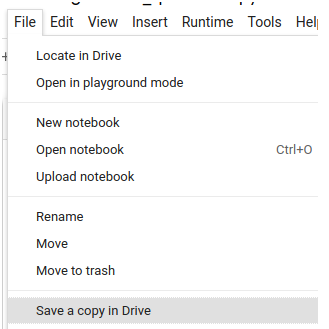

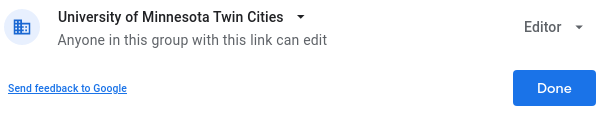


# References

1. google search AI -  what does this error indicate, `UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size. return F.mse_loss(input, target, reduction=self.reduction)` - I got an answer to use squeeze or to use torch.tensors, and I used tensor in the model for task 1 and squeeze in task 2.

2. google search AI - What is the function to concat tensors in torch - gave me the function torch.cat that i used for MLP


# Part 0 -- included setup


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda')

NOTE -- Pytorch should be pre-installed. so we don't need to install it in colab. You will need to install it locally if you wish to run this code locally

Pytorch has VERY EXPLICIT support for running code on different computing devices (I.E. CPU vs. GPU) If the above says `device(type='cpu')` you're using a runtime that only supports CPU. For faster runtimes you may wish to go to the `runtime` menu and change runtime to a GPU accelerated option. You may also find it valuable to set up [free colab pro under your student status](https://research.google.com/colaboratory/faq.html#edu-faq-heading) to get longer runtimes and access to more powerful GPU


In [2]:
!wget -nc https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -n 'ml-100k.zip'
!cat ml-100k/README

--2026-04-15 22:58:10--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  14.1MB/s    in 0.3s    

2026-04-15 22:58:11 (14.1 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.auto import tqdm


In [4]:
ratings = pd.read_csv("ml-100k/u.data",
                      delimiter="\t",
                      names=["userId", "itemId", "rating", "tstamp"],
                      engine='python')
ratings

,userId,itemId,rating,tstamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [5]:
# Attribution: Google's search AI helped me prep and update this code

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# indicate ids as cateorical
ratings['userId'] = ratings['userId'].astype('category').cat.codes
ratings['itemId'] = ratings['itemId'].astype('category').cat.codes
print(ratings['itemId'].min())
print(ratings['itemId'].max())
print(len(ratings['itemId'].unique()))
n_users = len(ratings['userId'].unique())
n_items = len(ratings['itemId'].unique())

# Split the data into training and testing sets
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

# Create a "Dataset" class for movielens
class MovieLensDataset(Dataset):
    def __init__(self, df):
        self.user_ids = torch.tensor(df['userId'].values, dtype=torch.long)
        self.movie_ids = torch.tensor(df['itemId'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.user_ids[idx], self.movie_ids[idx], self.ratings[idx]

# Create datasets for basic train and test tasks
train_dataset = MovieLensDataset(train_df)
test_dataset = MovieLensDataset(test_df)

0
1681
1682


# Task 1: Observe and improve Matrix Factorization

Below is a slightly updated version of the code available [in a useful medium article](https://www.google.com/url?q=https%3A%2F%2Fmedium.com%2F%40datadote%2Fpytorch-matrix-factorization-pictures-code-part-1-abe331317ffb) This implements a functional (if not somewhat primative) matrix factorization recommender as a neural net model.

The code block below that is a somewhat over-developed bit of code for training this model and producing some intermediary values to help understand the training quality.

You've got a few tasks here:

1. Read this code and make sure you understand it.
2. Run this code and make sure it works.
3. Improve this code. Specifically, Add per-user, per-item, and global intercept values: $\mu_u$, $\mu_i$, and $\mu$ so the prediction equation becomes $$\hat{R}_{ui} = \vec{P_u}\cdot\vec{Q_i} + \mu_u + \mu_i + \mu$$
4. Explore parameter tweaks and different optimizers. Don't chase this task forever, but at a minimum
    * Look up how to tweak the learning rate and regularization on the SGD optimizer
    * Test at least one other number `emb_dim` (or $K$ as we've been using in class -- the number of "Features" / size of the P and Q matrixes)
    * Look at _other_ optimizers and see if you can find one that is faster at no accuracy cost. (I recommend trying AdamW -- it seems quite popular)
4. Train the model again and report the improvement in quality (as indicated by the "validation" loss -- which is just the average test-set RMSE)


In [6]:
# A simplistic model showing matrix factoriztaion through a neural net lens
class MF(nn.Module):
    """ Matrix factorization model simple """
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        # Create embedding look ups for user and item -- this assigns each user, and each item a emb_dim vector of values
        self.user_emb = nn.Embedding(num_embeddings=num_users, embedding_dim=emb_dim)
        self.item_emb = nn.Embedding(num_embeddings=num_items, embedding_dim=emb_dim)

    # forward is a rough match for "estimate" in surprise.
    # We don't have to define the training step at all. When "forward" is run a computation graph is derived to create the network
    def forward(self, user, item):
        # get the P and Q vectors
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        # take a dot product
        element_product = torch.dot(user_emb, item_emb)
        # return it.
        return element_product

In [ ]:
# set up a model for training.
mdl = MF(n_users, n_items, emb_dim=32)
mdl.to(device)

MF(
  (user_emb): Embedding(943, 32)
  (item_emb): Embedding(1682, 32)
)

In [ ]:
# And here's our training loop. I tried to annotate what it's doing at different
# steps to help you track what is pytorch specific and what's just basic loops and data management.

from tqdm.auto import tqdm

# loop over dataset 10 times (might be a bit small)
NUM_EPOCHS = 10

# optimize by stochastic gradient descent on all model parameters
# use default values for regularization and learning rate
opt = torch.optim.SGD(mdl.parameters())
# use a mean-squared error loss
loss_fn = nn.MSELoss()

# track training and test loss values over time.
epoch_train_losses, epoch_val_losses = [], []

for i in tqdm(range(NUM_EPOCHS), position=0, desc="epoch"):
    train_losses, val_losses = [], []

    # set the model into "training mode"
    mdl.train()
    for uid, mid, rating in tqdm(train_dataset, position=1, leave=False, desc="train loop"):
        # reset all gradient computations
        opt.zero_grad()

        # convert data to pytortch types
        xUser = uid.to(device, dtype=torch.long)
        xItem = mid.to(device, dtype=torch.long)
        yRatings = rating.to(device, dtype=torch.float)

        # get the current prediction
        preds = mdl(xUser, xItem)
        # Apply the loss
        loss = loss_fn(preds, yRatings)
        train_losses.append(loss.item())

        # work backwards from the "end" of the process here to compute gradients
        loss.backward()

        # apply gradient descent update to all parameters
        opt.step()

    mdl.eval()  # switch to evaluation mode for a RMSE evaluation
    for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"): # Compute MSE for test ratings!
        xUser = uid.to(device, dtype=torch.long)
        xItem = mid.to(device, dtype=torch.long)
        yRatings = rating.to(device, dtype=torch.float)
        preds = mdl(xUser, xItem)
        loss = loss_fn(preds, yRatings)
        val_losses.append(loss.item())
    # Start logging
    epoch_train_loss = np.sqrt(np.mean(train_losses))
    epoch_val_loss = np.sqrt(np.mean(val_losses))
    epoch_train_losses.append(epoch_train_loss)
    epoch_val_losses.append(epoch_val_loss)
    display(f'Epoch: {i}, Train Loss: {epoch_train_loss:0.1f}, Val Loss:{epoch_val_loss:0.1f}')

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 0, Train Loss: 5.9, Val Loss:5.2'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

...

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 8, Train Loss: 1.5, Val Loss:2.4'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 9, Train Loss: 1.4, Val Loss:2.3'

# Exploration and analysis!

Now that you've read the code, remember the following steps are required:

1. Improve this code. Specifically, Add per-user, per-item, and global intercept values: $\mu_u$, $\mu_i$, and $\mu$ so the prediction equation becomes $$\hat{R}_{ui} = \vec{P_u}\cdot\vec{Q_i} + \mu_u + \mu_i + \mu$$ (hint -- the second part of the referenced medium article shows how to do this if you need some syntax help!)
2. Explore parameter tweaks and different optimizers. Don't chase this task forever, but at a minimum
    * Look up how to tweak the learning rate and regularization on the [SGD optimizer](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
    * Test at least one other number `emb_dim` (or $K$ as we've been using in class -- the number of "Features" / size of the P and Q matrixes)
    * Look at _other_ optimizers and see if you can find one that is faster at no accuracy cost. (I recommend trying [AdamW](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html) -- it seems quite popular)
3. Train the model again and report the improvement in quality (as indicated by the "validation" loss -- which is just the average test-set RMSE)

To get credit, in the following "text block" document what you tested, and how it changed RMSE. We don't need pictures or code -- just edit above and document your ultimate findings below.

If you think you've gotten **the best** RMSE in class -- post on slack #questions-assignments to see if anyone can beat your score! (You'll pretty quickly see how the community could get so obsessed with reducing RMSE -- it's kind of fun)


In [ ]:
## Add user, item and global intercept

class MF_Explore(nn.Module):
    """ Matrix factorization model simple """
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        self.user_emb = nn.Embedding(num_embeddings=num_users, embedding_dim=emb_dim)
        self.item_emb = nn.Embedding(num_embeddings=num_items, embedding_dim=emb_dim)
        self.user_bias = nn.Parameter(torch.zeros(num_users))
        self.item_bias = nn.Parameter(torch.zeros(num_items))
        # self.global_intercept = nn.Parameter(torch.zeros(1))
        self.global_intercept = nn.Parameter(torch.tensor(0.0))

    def forward(self, user, item):

        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        user_b = self.user_bias[user]
        item_b = self.item_bias[item]

        element_product = (user_emb*item_emb).sum(dim=-1)
        pred = element_product + user_b + item_b + self.global_intercept

        return pred

In [ ]:
mdl = MF_Explore(n_users, n_items, emb_dim=32)
mdl.to(device)

NUM_EPOCHS = 10

opt = torch.optim.SGD(mdl.parameters())
loss_fn = nn.MSELoss()
epoch_train_losses, epoch_val_losses = [], []

for i in tqdm(range(NUM_EPOCHS), position=0, desc="epoch"):
    train_losses, val_losses = [], []

    mdl.train()
    for uid, mid, rating in tqdm(train_dataset, position=1, leave=False, desc="train loop"):
        opt.zero_grad()

        xUser = uid.to(device, dtype=torch.long)
        xItem = mid.to(device, dtype=torch.long)
        yRatings = rating.to(device, dtype=torch.float)

        preds = mdl(xUser, xItem)
        loss = loss_fn(preds, yRatings)
        train_losses.append(loss.item())

        loss.backward()
        opt.step()

    mdl.eval()
    with torch.no_grad():
      for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"):
          xUser = uid.to(device, dtype=torch.long)
          xItem = mid.to(device, dtype=torch.long)
          yRatings = rating.to(device, dtype=torch.float)
          preds = mdl(xUser, xItem)
          loss = loss_fn(preds, yRatings)
          val_losses.append(loss.item())

    epoch_train_loss = np.sqrt(np.mean(train_losses))
    epoch_val_loss = np.sqrt(np.mean(val_losses))
    epoch_train_losses.append(epoch_train_loss)
    epoch_val_losses.append(epoch_val_loss)
    display(f'Epoch: {i}, Train Loss: {epoch_train_loss:0.1f}, Val Loss:{epoch_val_loss:0.1f}')

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 0, Train Loss: 4.7, Val Loss:3.9'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

...

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 8, Train Loss: 1.3, Val Loss:2.0'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 9, Train Loss: 1.2, Val Loss:2.0'

In [ ]:
# Adam Optimizer

mdl = MF_Explore(n_users, n_items, emb_dim=32)
mdl.to(device)

NUM_EPOCHS = 10

opt = torch.optim.AdamW(mdl.parameters())
loss_fn = nn.MSELoss()
epoch_train_losses, epoch_val_losses = [], []

for i in tqdm(range(NUM_EPOCHS), position=0, desc="epoch"):
    train_losses, val_losses = [], []

    mdl.train()
    for uid, mid, rating in tqdm(train_dataset, position=1, leave=False, desc="train loop"):
        opt.zero_grad()

        xUser = uid.to(device, dtype=torch.long)
        xItem = mid.to(device, dtype=torch.long)
        yRatings = rating.to(device, dtype=torch.float)

        preds = mdl(xUser, xItem)
        loss = loss_fn(preds, yRatings)
        train_losses.append(loss.item())

        loss.backward()
        opt.step()

    mdl.eval()
    with torch.no_grad():
      for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"):
          xUser = uid.to(device, dtype=torch.long)
          xItem = mid.to(device, dtype=torch.long)
          yRatings = rating.to(device, dtype=torch.float)
          preds = mdl(xUser, xItem)
          loss = loss_fn(preds, yRatings)
          val_losses.append(loss.item())

    epoch_train_loss = np.sqrt(np.mean(train_losses))
    epoch_val_loss = np.sqrt(np.mean(val_losses))
    epoch_train_losses.append(epoch_train_loss)
    epoch_val_losses.append(epoch_val_loss)
    display(f'Epoch: {i}, Train Loss: {epoch_train_loss:0.1f}, Val Loss:{epoch_val_loss:0.1f}')


epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 0, Train Loss: 2.9, Val Loss:1.1'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

...

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 8, Train Loss: 0.8, Val Loss:0.9'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 9, Train Loss: 0.8, Val Loss:0.9'

In [ ]:
# SGD with embedding size 16

mdl = MF_Explore(n_users, n_items, emb_dim=16)
mdl.to(device)

NUM_EPOCHS = 10

opt = torch.optim.SGD(mdl.parameters())
loss_fn = nn.MSELoss()
epoch_train_losses, epoch_val_losses = [], []

for i in tqdm(range(NUM_EPOCHS), position=0, desc="epoch"):
    train_losses, val_losses = [], []

    mdl.train()
    for uid, mid, rating in tqdm(train_dataset, position=1, leave=False, desc="train loop"):
        opt.zero_grad()

        xUser = uid.to(device, dtype=torch.long)
        xItem = mid.to(device, dtype=torch.long)
        yRatings = rating.to(device, dtype=torch.float)

        preds = mdl(xUser, xItem)
        loss = loss_fn(preds, yRatings)
        train_losses.append(loss.item())

        loss.backward()
        opt.step()

    mdl.eval()
    with torch.no_grad():
      for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"):
          xUser = uid.to(device, dtype=torch.long)
          xItem = mid.to(device, dtype=torch.long)
          yRatings = rating.to(device, dtype=torch.float)
          preds = mdl(xUser, xItem)
          loss = loss_fn(preds, yRatings)
          val_losses.append(loss.item())

    epoch_train_loss = np.sqrt(np.mean(train_losses))
    epoch_val_loss = np.sqrt(np.mean(val_losses))
    epoch_train_losses.append(epoch_train_loss)
    epoch_val_losses.append(epoch_val_loss)
    display(f'Epoch: {i}, Train Loss: {epoch_train_loss:0.1f}, Val Loss:{epoch_val_loss:0.1f}')


epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 0, Train Loss: 3.4, Val Loss:2.8'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

...

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 8, Train Loss: 1.2, Val Loss:1.5'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 9, Train Loss: 1.1, Val Loss:1.4'

In [ ]:
# SGD tuning: learning rate + weight decay together

NUM_EPOCHS = 10

lrs = [0.005, 0.001]
wds = [0.0001, 0.001]

results = {}

for lr in lrs:
  for wd in wds:

    print(f"\nRunning model with lr={lr}, weight_decay={wd}")

    mdl = MF_Explore(n_users, n_items, emb_dim=32)
    mdl.to(device)

    opt = torch.optim.SGD(mdl.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()
    epoch_train_losses, epoch_val_losses = [], []

    for i in tqdm(range(NUM_EPOCHS), position=0, desc=f"epoch lr={lr}, wd={wd}"):
        train_losses, val_losses = [], []

        mdl.train()
        for uid, mid, rating in tqdm(train_dataset, position=1, leave=False, desc="train loop"):
            opt.zero_grad()

            xUser = uid.to(device, dtype=torch.long)
            xItem = mid.to(device, dtype=torch.long)
            yRatings = rating.to(device, dtype=torch.float)

            preds = mdl(xUser, xItem)
            loss = loss_fn(preds, yRatings)
            train_losses.append(loss.item())

            loss.backward()
            opt.step()

        mdl.eval()
        with torch.no_grad():
          for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"):
              xUser = uid.to(device, dtype=torch.long)
              xItem = mid.to(device, dtype=torch.long)
              yRatings = rating.to(device, dtype=torch.float)

              preds = mdl(xUser, xItem)
              loss = loss_fn(preds, yRatings)
              val_losses.append(loss.item())

        epoch_train_loss = np.sqrt(np.mean(train_losses))
        epoch_val_loss = np.sqrt(np.mean(val_losses))
        epoch_train_losses.append(epoch_train_loss)
        epoch_val_losses.append(epoch_val_loss)

        display(f'Epoch: {i+1}, lr: {lr}, wd: {wd}, Train RMSE: {epoch_train_loss:.4f}, Val RMSE: {epoch_val_loss:.4f}')

    # store final validation RMSE
    final_rmse = epoch_val_losses[-1]
    results[(lr, wd)] = final_rmse

    print(f"Final Validation RMSE for lr={lr}, wd={wd}: {final_rmse:.4f}")


Running model with lr=0.005, weight_decay=0.0001


epoch lr=0.005, wd=0.0001:   0%|          | 0/10 [00:00<?, ?it/s]

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 1, lr: 0.005, wd: 0.0001, Train RMSE: 3.2729, Val RMSE: 2.0395'

...

'Epoch: 9, lr: 0.001, wd: 0.001, Train RMSE: 0.9684, Val RMSE: 1.1089'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 10, lr: 0.001, wd: 0.001, Train RMSE: 0.9459, Val RMSE: 1.0707'

Final Validation RMSE for lr=0.001, wd=0.001: 1.0707


## ANS:

1. Baseline SGD (no bias terms)
The baseline model had a relatively high RMSE (2.3) and learned quite slowly over epochs. Since it didn't include any bias terms, it couldn't capture user or item tendencies well.

2. Adding bias terms
After adding bias terms, the RMSE improved to around 2.0 and the model converged a bit faster. This helped account for consistent user and item rating patterns early in training.

3. Adam optimizer
Switching to Adam gave a big improvement, reducing RMSE to 0.9. It also converged much faster than SGD, with a sharp drop in loss in the first few epochs and saturated later.

4. Embedding size change from 32 to 16 (SGD)
Reducing the embedding size to 16 improved RMSE to 1.4 and made training faster. The smaller model likely reduced overfitting while still capturing enough interaction information.

5. SGD tuning: lr = 0.005, wd = 0.0001
With a higher learning rate, the model converged quickly and reached RMSE 1.17, but showed some overfitting. Lower regularization allowed faster learning but less stability.

6. SGD tuning: lr = 0.005, wd = 0.001
This combination worked best for SGD, reaching RMSE 0.97 with smooth and stable convergence. The added regularization helped generalization without slowing training.

7. SGD tuning: lr = 0.001, wd = 0.0001
With a lower learning rate, convergence was much slower, and RMSE only reduced to 1.79. The model learned gradually but underfit due to insufficient update steps.

8. SGD tuning: lr = 0.001, wd = 0.001
Adding weight decay improved performance slightly to 1.07, but convergence was still slower than higher learning rates. The model generalized better than wd=0.0001 but remained less effective overall.


# Task 2: GMF Algorithm

In [Neural Collaborative Filtering](https://dl.acm.org/doi/10.1145/3038912.3052569) section 3.2 they document the GMF model. This is ultimately a small change over the Matrix factorization model above. By my read -- the biggest change is swapping out the dot-product for a pairwise multiplication to the vectors and slapping a final linear layer (`nn.Linear`) at the end to compute the final output with _weights_ and possibly an output layer.

(Note -- we're currently tuning for rating-prediction, so most activation functions are not worth it -- a linear model should be fine)


In [7]:
# Code for GMF -- if you wish to test it make a new code block under this one -- but you can also test everything "together" in task 6

class GMF(nn.Module):
    """ Matrix factorization model simple """
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        self.user_emb = nn.Embedding(num_embeddings=num_users, embedding_dim=emb_dim)
        self.item_emb = nn.Embedding(num_embeddings=num_items, embedding_dim=emb_dim)
        self.lin = nn.Linear(in_features=emb_dim, out_features=1)

    def forward(self, user, item):
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)
        element_product = user_emb * item_emb
        element_product = self.lin(element_product)
        return element_product.squeeze(-1)

# Task 3: MLP Algorithm

In [Neural Collaborative Filtering](https://dl.acm.org/doi/10.1145/3038912.3052569) section 3.3 they document the MLP model. A few more details about the exact shape are provided later in the end of section 4.1.

This model will be a bigger change than the previous one as they take the embedding vectors and concatenate them. (so if you have an embdding size 16, you would now have a vector size 32). After doing this they feed the new joined vector through a series of neural net layers all with ReLU activation functions (with the output of one being the input to the next and so-forth). The final output is then fed to a final linear layer to reduce it to 1 output value as before.

Note -- you will likely need an alternating combination of `nn.Linear` objects and `nn.ReLU` objects to achive this as "activation functions" are seperate steps in pytorch.

In section 4.1 they document that, while any sequence of sizes for these layers could be used, they primarily tested with 3 hidden layers (so 4 layers if you count the "first" layer which takes the concatenated input), the first being as large as the concatenation, and the rest being half as small as the preceeding.

Since this is a bit unclear (without going to their raw source-code like I did), an example may help. If you have an embedding size of 32, then:
* the concatenation gives you a vector of size 64.
* the "input layer" would take that size 64 input and produce an ouput of size 64
* "hidden layer 1" would have 64 inputs and 32 outputs
* "hidden layer 2" would have 32 inputs to 16 outputs
* "hidden layer 3" would have 16 inputs and 8 outputs
* The output layer would have 8 inputs and 1 output.


In [8]:
# Code for MLP -- if you wish to test it make a new code block under this one -- but you can also test everything "together" in task 6

class MLP_MF(nn.Module):
    """ Matrix factorization model simple """
    def __init__(self, num_users, num_items, emb_dim = 32):
        super().__init__()
        self.user_emb = nn.Embedding(num_embeddings=num_users, embedding_dim=emb_dim)
        self.item_emb = nn.Embedding(num_embeddings=num_items, embedding_dim=emb_dim)

        self.fc1 = nn.Linear(in_features=64, out_features=64)
        self.fc2 = nn.Linear(in_features=64, out_features=32)
        self.fc3 = nn.Linear(in_features=32, out_features=16)
        self.fc4 = nn.Linear(in_features=16, out_features=8)
        self.fc5 = nn.Linear(in_features=8, out_features=1)

        self.relu = nn.ReLU()

    def forward(self, user, item):
        user_emb = self.user_emb(user)
        item_emb = self.item_emb(item)

        x = torch.cat([user_emb, item_emb], dim=-1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)

        return x.squeeze(-1)


# Task 4: NeuMF Algorithm

In [Neural Collaborative Filtering](https://dl.acm.org/doi/10.1145/3038912.3052569) section 3.4 they document the NeuMf model. A few more details about the exact shape are provided later in the end of section 4.1.

This model is essentially a hybrid of the last two. Each model runs independnelty (even having it's own seperate embeddings) until just at the end. Both models have their "output layers" removed (so in GMF we would perform the pairwise multiplcation but wouldn't have it's final linear layer, and MLP would have it's "hidden" layers, but would directly output their final values) the final vectors produced by the GMF subnet and MLP subnet are then concatenated and fed into one final linear layer.


In [9]:
# Code for NeuMF -- if you wish to test it make a new code block under this one -- but you can also test everything "together" in task 6

class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32):
        super().__init__()

        # GMF embeddings
        self.user_emb_gmf = nn.Embedding(num_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(num_items, emb_dim)

        # MLP embeddings
        self.user_emb_mlp = nn.Embedding(num_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(num_items, emb_dim)

        # MLP layers
        self.fc1 = nn.Linear(64, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 8)

        self.relu = nn.ReLU()

        # final layer
        self.final = nn.Linear(40, 1)

    def forward(self, user, item):
        # GMF
        user_emb_gmf = self.user_emb_gmf(user)
        item_emb_gmf = self.item_emb_gmf(item)
        gmf_out = user_emb_gmf * item_emb_gmf

        # MLP
        user_emb_mlp = self.user_emb_mlp(user)
        item_emb_mlp = self.item_emb_mlp(item)
        x = torch.cat([user_emb_mlp, item_emb_mlp], dim=-1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        mlp_out = self.relu(self.fc4(x))

        # GMF + MLP
        combined = torch.cat([gmf_out, mlp_out], dim=-1)
        out = self.final(combined)

        return out.squeeze(-1)

# Task 5: Learning To Rank

So this isn't quite "part of" the replication, but it would be a shame not to show how easy it is to do in this framework.

Below is a provided loss function for BPR's learning to rank model.


In [10]:
# Note -- I have to give credit where it's due. This version of the code was written by google's search results AI.
# A good side-note to be careful about expanding those search results if you don't want to see code!

import torch
import torch.nn as nn
import torch.nn.functional as F

class BPRLoss(nn.Module):
    def __init__(self, regularization_weight=0.01):
        super(BPRLoss, self).__init__()
        self.regularization_weight = regularization_weight

    def forward(self, positive_predictions, negative_predictions, model_parameters=None): # NOTE -- model parameters are optional and probably not needed for us. regularization is handeled by our optimizer
        # Calculate the difference between positive and negative scores
        # The BPR objective is to maximize this difference
        score_difference = positive_predictions - negative_predictions

        # The core BPR loss is the negative log-sigmoid of the score difference
        # F.logsigmoid(x) is more numerically stable than log(sigmoid(x))
        bpr_loss = -F.logsigmoid(score_difference).mean()

        # Add L2 regularization if model parameters are provided
        if model_parameters is not None:
            l2_reg = sum(p.norm(2) for p in model_parameters)
            bpr_loss += self.regularization_weight * l2_reg

        return bpr_loss


As you can see -- a loss function is simply another bit of neural net that we can chain together. The one difficult part you will have to handle is **how do we train this?** That will be a bit of a challenge since you will need to implement the "sampling" strategy introduced in the BPR paper:
 * pick a random user
 * Pick a random "positive" example (something they have seen)
 * Pick a random "negative" example (something they have not seen)
 * Train on this triple

You will need to create some extra data management to make training like this possible. (hint -- do this from the raw pandas data frames may WAY earlier in this document -- maybe make a "seen" list for each user and a "all items" list. Just don't forget to turn these back into appropriate pytorch data types later if needed)

For this section: Pick a base model and train it with the BPR loss function.


In [11]:
import random

train_user_seen = train_df.groupby("userId")["itemId"].apply(set).to_dict()
test_user_seen = test_df.groupby("userId")["itemId"].apply(set).to_dict()

all_items = set(train_df['itemId']) | set(test_df['itemId'])
train_users = list(train_user_seen.keys())
test_users = list(test_user_seen.keys())

print("Unique train users:", len(train_users))
print("Unique test users:", len(test_users))

def sample_bpr_triplet(user_seen_dict, user_list, all_items):
    u = random.choice(user_list)
    pos_item = random.choice(list(user_seen_dict[u]))
    neg_item = random.choice(list(all_items - user_seen_dict[u]))
    return u, pos_item, neg_item

Unique train users: 943
Unique test users: 940


# Part 6 - Final evaluation

1. If you haven't already -- train all 5 models (MF, GMF, MLP, NeuCF, BPR-modified)
2. Once that's done -- use the test set to evaluate the models. Please report RMSE and precision for each.
   * Because precision is a recommendation metric this will impact your evaluation. The evaluation loop will need to loop per-user not per-rating in the testing dataset.
   * For precision simulate a top-10 list. Do not recommend items that have already been rated in the training set. "good items" are those that are in the test-set.
   * There is not a precision metric built-in to pytorch. You will need to hand-code this -- if you can find a pre-built you can use that too, but precision is often easy to build and you can likely re-use code from the last project for this.
   * Because the preision value is computed per-user, please also compute a per-user RMSE value.
   * Report final values averaged over all users. So an average precision and an average per-user RMSE.
3. Once you have your results, please write a breif paragraph documenting what you found and how you interpret it.


In [12]:
# train MF, GMF, MLP, NeuCF

def train_model(model):
    model = model.to(device)
    NUM_EPOCHS = 10

    # optimize by stochastic gradient descent on all model parameters
    # use default values for regularization and learning rate
    opt = torch.optim.SGD(model.parameters())
    # use a mean-squared error loss
    loss_fn = nn.MSELoss()

    # track training and test loss values over time.
    epoch_train_losses, epoch_val_losses = [], []

    for i in tqdm(range(NUM_EPOCHS), position=0, desc="epoch"):
        train_losses, val_losses = [], []

        # set the model into "training mode"
        model.train()
        for uid, mid, rating in tqdm(train_dataset, position=1, leave=False, desc="train loop"):
            # reset all gradient computations
            opt.zero_grad()

            # convert data to pytortch types
            xUser = uid.to(device, dtype=torch.long)
            xItem = mid.to(device, dtype=torch.long)
            yRatings = rating.to(device, dtype=torch.float)

            # get the current prediction
            preds = model(xUser, xItem)
            # Apply the loss
            loss = loss_fn(preds, yRatings)
            train_losses.append(loss.item())

            # work backwards from the "end" of the process here to compute gradients
            loss.backward()

            # apply gradient descent update to all parameters
            opt.step()

        model.eval()  # switch to evaluation mode for a RMSE evaluation
        for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"): # Compute MSE for test ratings!
            xUser = uid.to(device, dtype=torch.long)
            xItem = mid.to(device, dtype=torch.long)
            yRatings = rating.to(device, dtype=torch.float)
            preds = model(xUser, xItem)
            loss = loss_fn(preds, yRatings)
            val_losses.append(loss.item())
        # Start logging
        epoch_train_loss = np.sqrt(np.mean(train_losses))
        epoch_val_loss = np.sqrt(np.mean(val_losses))
        epoch_train_losses.append(epoch_train_loss)
        epoch_val_losses.append(epoch_val_loss)
        display(f'Epoch: {i}, Train Loss: {epoch_train_loss:0.4f}, Val Loss:{epoch_val_loss:0.4f}')

    return model, epoch_train_losses, epoch_val_losses

In [13]:
def train_bpr_model(model):
    model = model.to(device)
    NUM_EPOCHS = 10

    opt = torch.optim.SGD(model.parameters())
    loss_fn = BPRLoss()
    eval_loss_fn = nn.MSELoss()

    epoch_train_losses, epoch_val_losses = [], []
    SAMPLES_PER_EPOCH = len(train_df)

    for i in tqdm(range(NUM_EPOCHS), position=0, desc="epoch"):
        train_losses, val_losses = [], []

        model.train()
        for _ in tqdm(range(SAMPLES_PER_EPOCH), position=1, leave=False, desc="train loop"):
          # train with sampling
          # assumption - sample n times just as other models where n = number of ratings
            u, pos_i, neg_i = sample_bpr_triplet(train_user_seen, train_users, all_items)

            xUser = torch.tensor([u], device=device, dtype=torch.long)
            xPosItem = torch.tensor([pos_i], device=device, dtype=torch.long)
            xNegItem = torch.tensor([neg_i], device=device, dtype=torch.long)

            opt.zero_grad()

            pos_preds = model(xUser, xPosItem)
            neg_preds = model(xUser, xNegItem)

            loss = loss_fn(pos_preds, neg_preds)
            train_losses.append(loss.item())

            loss.backward()
            opt.step()

        model.eval()
        # using rmse here for simplicity of assignment - evaluation per user computed later
        for uid, mid, rating in tqdm(test_dataset, position=1, leave=False, desc="test loop"):
            xUser = uid.to(device, dtype=torch.long)
            xItem = mid.to(device, dtype=torch.long)
            yRatings = rating.to(device, dtype=torch.float)

            preds = model(xUser, xItem)
            loss = eval_loss_fn(preds, yRatings)
            val_losses.append(loss.item())

        epoch_train_loss = np.mean(train_losses)
        epoch_val_loss = np.sqrt(np.mean(val_losses))

        epoch_train_losses.append(epoch_train_loss)
        epoch_val_losses.append(epoch_val_loss)

        display(f'Epoch: {i}, Train BPR Loss: {epoch_train_loss:0.4f}')

    return model, epoch_train_losses, epoch_val_losses

In [14]:
mf_model = MF(n_users, n_items, emb_dim=32)
mf_model, mf_train, mf_val = train_model(
    mf_model)

gmf_model = GMF(n_users, n_items, emb_dim=32)
gmf_model, gmf_train, gmf_val = train_model(
    gmf_model)

mlp_model = MLP_MF(n_users, n_items, emb_dim=32)
mlp_model, mlp_train, mlp_val = train_model(
    mlp_model)

neumf_model = NeuMF(n_users, n_items, emb_dim=32)
neumf_model, neumf_train, neumf_val = train_model(
    neumf_model)

bpr_model = MLP_MF(n_users, n_items, emb_dim=32)
bpr_model, bpr_train, bpr_val = train_bpr_model(bpr_model)

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 0, Train Loss: 5.8604, Val Loss:5.2300'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

...

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 8, Train BPR Loss: 0.3369'

train loop:   0%|          | 0/80000 [00:00<?, ?it/s]

test loop:   0%|          | 0/20000 [00:00<?, ?it/s]

'Epoch: 9, Train BPR Loss: 0.3297'

In [15]:
print("Final MF Train Loss:", mf_train[-1])
print("Final MF Val Loss:", mf_val[-1])

print("Final GMF Train Loss:", gmf_train[-1])
print("Final GMF Val Loss:", gmf_val[-1])

print("Final MLP Train Loss:", mlp_train[-1])
print("Final MLP Val Loss:", mlp_val[-1])

print("Final NeuMF Train Loss:", neumf_train[-1])
print("Final NeuMF Val Loss:", neumf_val[-1])

print("Final BPR with GMF Train Loss:", bpr_train[-1])
print("Final BPR with GMF Val Loss:", bpr_val[-1])

Final MF Train Loss: 1.3844123637734478
Final MF Val Loss: 2.3247863358002614
Final GMF Train Loss: 1.1440543505052274
Final GMF Val Loss: 1.1448133745121682
Final MLP Train Loss: 0.9673373224040825
Final MLP Val Loss: 1.0240765771238767
Final NeuMF Train Loss: 0.9811743664418611
Final NeuMF Val Loss: 1.0424898751617
Final BPR with GMF Train Loss: 0.32965084177434584
Final BPR with GMF Val Loss: 1.7228183632357286


In [16]:
from collections import defaultdict
import numpy as np
import pandas as pd

def compute_per_user_rmse(model, test_df):
    user_sq_errors = defaultdict(list)

    model.eval()
    with torch.no_grad():
        for row in test_df.itertuples(index=False):
            u = int(row.userId)
            i = int(row.itemId)
            r = float(row.rating)

            xUser = torch.tensor(u, dtype=torch.long, device=device)
            xItem = torch.tensor(i, dtype=torch.long, device=device)

            pred = model(xUser, xItem).item()
            user_sq_errors[u].append((pred - r) ** 2)

    per_user_rmse = [np.sqrt(np.mean(errs)) for errs in user_sq_errors.values()]
    return float(np.mean(per_user_rmse))

In [17]:
def precision(item_list, good_items):
    item_set = set(item_list)
    good_set = set(good_items)
    return len(item_set.intersection(good_set)) / len(item_set)


def compute_precision_at_10(model, train_user_seen, test_user_seen, all_items, k=10):
    precisions = []

    model.eval()
    with torch.no_grad():
        for u in test_user_seen:
            train_items = train_user_seen.get(u, set())
            good_items = test_user_seen[u]

            candidate_items = list(all_items - train_items)

            scores = []
            for item in candidate_items:
                xUser = torch.tensor(u, dtype=torch.long, device=device)
                xItem = torch.tensor(item, dtype=torch.long, device=device)

                score = model(xUser, xItem).item()
                scores.append((item, score))

            top_k = sorted(scores, key=lambda x: x[1], reverse=True)[:k]
            recommended_items = [item for item, _ in top_k]

            precisions.append(precision(recommended_items, good_items))

    return float(np.mean(precisions))

In [18]:
results = []

models = {
    "MF": mf_model,
    "GMF": gmf_model,
    "MLP": mlp_model,
    "NeuMF": neumf_model,
    "BPR-modified": bpr_model
}

for name, model in models.items():
    print("Model :", name)
    avg_user_rmse = compute_per_user_rmse(model, test_df)
    avg_precision_10 = compute_precision_at_10(model, train_user_seen, test_user_seen, all_items)

    results.append({
        "Model": name,
        "Avg Per-User RMSE": avg_user_rmse,
        "Avg Precision@10": avg_precision_10
    })

results_df = pd.DataFrame(results)
results_df

Model : MF
Model : GMF
Model : MLP
Model : NeuMF
Model : BPR-modified


,Model,Avg Per-User RMSE,Avg Precision@10
0,MF,2.657113,0.010851
1,GMF,1.095763,0.014255
2,MLP,1.011890,0.045000
3,NeuMF,1.027624,0.041277
4,BPR-modified,1.656258,0.144681


#### Results analysis

**RMSE:**

- The Matrix factorization's performance is the least as it uses basic matrix factorization model with SGD and without any optimization of hyperparameters.
- BPR also has a high RMSE compared to others and performs better than MF. This is because the BPR model that was used is the MLP model.
- MLP performs the best on RMSE.
- Even though BPR uses the same model and SGD as MLP. BPR under performs significantly in comparision with MLP

**Precision**
- BPR performs the best, and beats the MLP model as well even though both use the same model structure.
- MLP is the next best, followed by NeuMF and GMF and MF at the end.

We can conclude that BPR performs really good on precision in comparision to others. As all of the models were tested on basic hyperparams without any tuning. And all models use SGD. This results in all models to under perform, but gives a baseline to compare all models with the same settings.
MLP performs the best overall in RMSE.
